# Drought Classification from CNN Regression Outputs

This notebook trains a Random Forest drought classifier on ground-truth physiological traits, then evaluates how well drought can be classified when using traits predicted by ResNet, EfficientNet, and Swin models.

In [31]:

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [32]:

# ------------------------------------------------------------------
# 1. Load lam train/val/test and train a Random Forest drought classifier
# ------------------------------------------------------------------

train_path = 'WHOLE/lam/training/train_resnet-lam-top-only-all-days.csv'
val_path   = 'WHOLE/lam/validation/validation_resnet-lam-top-only-all-days.csv'
test_path  = 'WHOLE/lam/test/test_resnet-lam-top-only-all-days.csv'

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

features = ['gsw', 'VPleaf', 'VPDleaf', 'H2O_leaf']

def derive_label(df: pd.DataFrame) -> pd.Series:
    if 'drought' in df.columns:
        return df['drought'].astype(int)
    if 'Pot ID' in df.columns:
        return df['Pot ID'].astype(str).str.upper().str.startswith('D').astype(int)
    raise KeyError('Could not derive drought labels')

for df in (train_df, val_df, test_df):
    df['label'] = derive_label(df)

X_train, y_train = train_df[features], train_df['label']
X_val,   y_val   = val_df[features],   val_df['label']
X_test,  y_test  = test_df[features],  test_df['label']

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

print("=== Validation (GT) ===")
print(accuracy_score(y_val, rf_clf.predict(X_val)))
print(confusion_matrix(y_val, rf_clf.predict(X_val)))
print(classification_report(y_val, rf_clf.predict(X_val)))

print("=== Test (GT) ===")
print(accuracy_score(y_test, rf_clf.predict(X_test)))
print(confusion_matrix(y_test, rf_clf.predict(X_test)))
print(classification_report(y_test, rf_clf.predict(X_test)))


=== Validation (GT) ===
0.8529411764705882
[[32  6]
 [ 4 26]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.86        38
           1       0.81      0.87      0.84        30

    accuracy                           0.85        68
   macro avg       0.85      0.85      0.85        68
weighted avg       0.86      0.85      0.85        68

=== Test (GT) ===
0.8125
[[20  8]
 [ 4 32]]
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.80      0.89      0.84        36

    accuracy                           0.81        64
   macro avg       0.82      0.80      0.81        64
weighted avg       0.81      0.81      0.81        64



In [33]:

# ------------------------------------------------------------------
# 2. Load CNN prediction CSVs
# ------------------------------------------------------------------

model_pred_files = {
    "ResNet":       "experiments_gh_gsw/predictions__resnet50_merged.csv",
    "EfficientNet": "experiments_gh_gsw/predictions__efficientnet_b5_merged.csv",
    "Swin":         "experiments_gh_gsw/predictions__swin_large_patch4_window12_384_merged.csv",
}

dfs = {}
for name, path in model_pred_files.items():
    df = pd.read_csv(path)
    df['gt_drought'] = df['image_file'].astype(str).str.upper().str.startswith('D').astype(int)
    dfs[name] = df

any_df = dfs['Swin']
y_true = any_df['gt_drought'].values

print("Loaded models:", list(dfs.keys()))
print("N samples:", len(any_df))


Loaded models: ['ResNet', 'EfficientNet', 'Swin']
N samples: 64



=== Metrics Table ===
Model	Acc	BalAcc	Prec	Rec	F1
GT	0.812	0.802	0.800	0.889	0.842
ResNet	0.688	0.694	0.767	0.639	0.697
EfficientNet	0.609	0.585	0.622	0.778	0.691
Swin	0.656	0.655	0.706	0.667	0.686


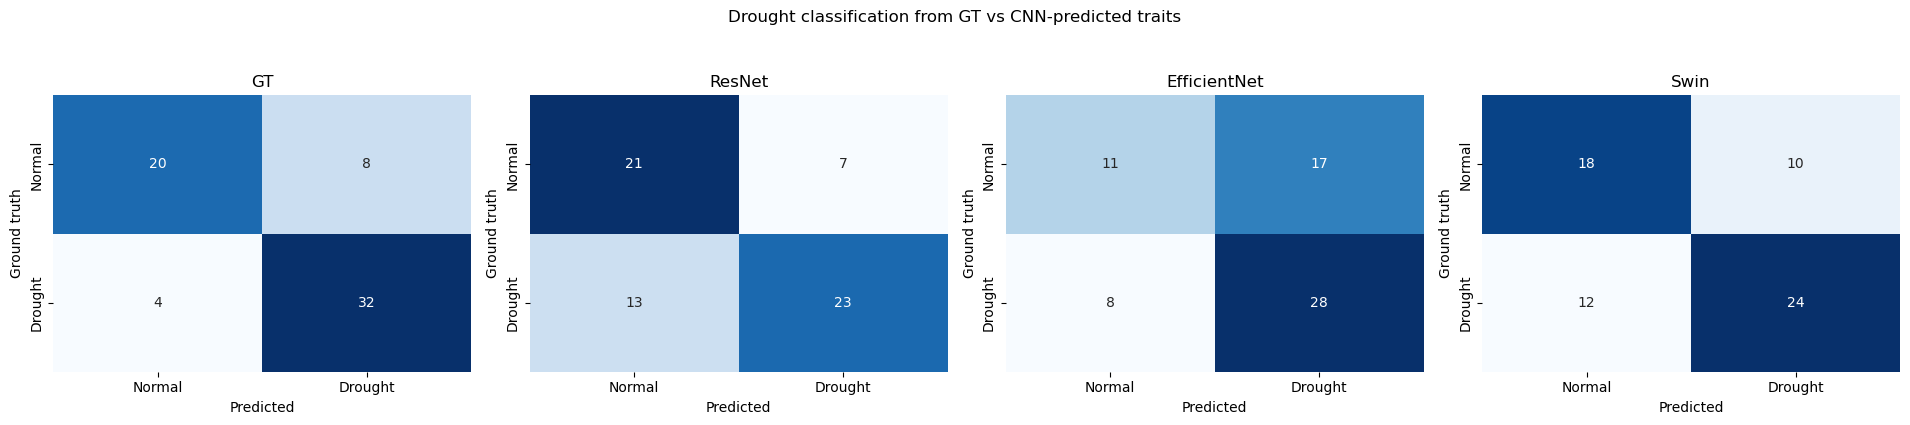

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# ------------------------------------------------------------------
# Helper to build X from *_gt or *_pred
# ------------------------------------------------------------------
def build_X(df, suffix):
    cols = [f"{t}{suffix}" for t in features]
    X = df[cols].copy()
    X.columns = features
    return X

# ------------------------------------------------------------------
# Bundle of metrics for printing + later tabulation
# ------------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, zero_division=0),
        "rec": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cm": confusion_matrix(y_true, y_pred),
    }

# ------------------------------------------------------------------
# Baseline: RF accuracy using **ground-truth physiological traits**
# ------------------------------------------------------------------
results = {}

y_pred_gt = rf_clf.predict(X_test)
results["GT"] = compute_metrics(y_test, y_pred_gt)

# ------------------------------------------------------------------
# CNN models — prediction CSV + merge with test_df
# ------------------------------------------------------------------
model_pred_files = {
    "ResNet":       "experiments_gh_gsw/predictions__resnet50_merged.csv",
    "EfficientNet": "experiments_gh_gsw/predictions__efficientnet_b5_merged.csv",
    "Swin":         "experiments_gh_gsw/predictions__swin_large_patch4_window12_384_merged.csv",
}

dfs = {}

for name, path in model_pred_files.items():
    pred_df = pd.read_csv(path)
    pred_df["image_file"] = pred_df["image_file"].astype(str)
    test_df["image_file"] = test_df["image_file"].astype(str)

    merged = test_df[["image_file", "label"]].merge(pred_df, on="image_file", how="inner")
    dfs[name] = merged

    X_pred = build_X(merged, "_pred")
    y_true = merged["label"].values
    y_pred = rf_clf.predict(X_pred)

    results[name] = compute_metrics(y_true, y_pred)

# ------------------------------------------------------------------
# Print metrics cleanly for table-building
# ------------------------------------------------------------------
print("\n=== Metrics Table ===")
print("Model\tAcc\tBalAcc\tPrec\tRec\tF1")
for name, r in results.items():
    print(
        f"{name}\t"
        f"{r['acc']:.3f}\t"
        f"{r['bal_acc']:.3f}\t"
        f"{r['prec']:.3f}\t"
        f"{r['rec']:.3f}\t"
        f"{r['f1']:.3f}"
    )

# ------------------------------------------------------------------
# Plot confusion matrices (figure stays clean)
# ------------------------------------------------------------------
order = ["GT", "ResNet", "EfficientNet", "Swin"]
fig, axes = plt.subplots(1, len(order), figsize=(4.8 * len(order), 4))

for ax, name in zip(axes, order):
    r = results[name]
    cm = r["cm"]
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=cm,
        fmt="d",
        cbar=False,
        xticklabels=["Normal", "Drought"],
        yticklabels=["Normal", "Drought"],
        cmap="Blues",
        ax=ax,
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")

plt.suptitle("Drought classification from GT vs CNN-predicted traits", y=1.05)
plt.tight_layout()
plt.show()


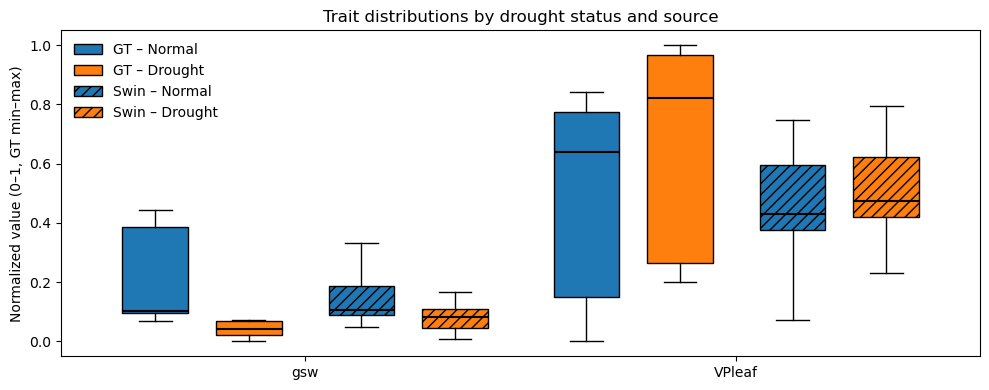

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
features = ['gsw', 'VPleaf']

df = dfs["Swin"]        # reference GT + Swin predictions
labels = df["label"].values  # 0 = normal, 1 = drought

# Colors
COL_NORMAL  = "#1f77b4"   # blue
COL_DROUGHT = "#ff7f0e"   # orange

fig, ax = plt.subplots(figsize=(10, 4))

positions = []
pos = 1.0

for t in features:
    gt   = df[f"{t}_gt"].values
    pred = df[f"{t}_pred"].values

    # --- Min–max normalization (GT only) ---
    gt_min = gt.min()
    gt_max = gt.max()
    denom = gt_max - gt_min if gt_max > gt_min else 1e-6

    gt_norm   = np.clip((gt   - gt_min) / denom, 0, 1)
    pred_norm = np.clip((pred - gt_min) / denom, 0, 1)

    # Split by drought status
    gt_d   = gt_norm[labels == 1]
    gt_n   = gt_norm[labels == 0]
    pred_d = pred_norm[labels == 1]
    pred_n = pred_norm[labels == 0]

    data = [gt_n, gt_d, pred_n, pred_d]
    xloc = [pos, pos + 0.5, pos + 1.1, pos + 1.6]

    bp = ax.boxplot(
        data,
        positions=xloc,
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.5),  # ✅ black median
    )

    # Styling boxes
    for i, box in enumerate(bp["boxes"]):
        is_gt   = i < 2
        is_norm = i in (0, 2)

        box.set_facecolor(COL_NORMAL if is_norm else COL_DROUGHT)
        box.set_edgecolor("black")

        if not is_gt:                # CNN prediction
            box.set_hatch("///")

    positions.append(pos + 0.8)
    pos += 2.3

# Axes
ax.set_xticks(positions)
ax.set_xticklabels(features)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("Normalized value (0–1, GT min–max)")
ax.set_title("Trait distributions by drought status and source")

# ✅ Fully explicit legend
legend_items = [
    Patch(facecolor=COL_NORMAL,  edgecolor="black", label="GT – Normal"),
    Patch(facecolor=COL_DROUGHT, edgecolor="black", label="GT – Drought"),
    Patch(facecolor=COL_NORMAL,  edgecolor="black", hatch="///", label="Swin – Normal"),
    Patch(facecolor=COL_DROUGHT, edgecolor="black", hatch="///", label="Swin – Drought"),
]

ax.legend(handles=legend_items, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()
